# Graph instances

For graph based-problems we will test on the following graphs. We give methods to generate named instances and also provide a rational as to why we study these graphs.

In [10]:
import json
import networkx as nx
import numpy as np

from qaoa_training_pipeline.utils.graph_utils import graph_to_dict

num_graphs = 10

## Random k regular

Random regular graphs are standard benchmarks for QAOA. Some parameter setting methods are even designed for these graphs.

In [18]:
save = False
degrees = [3, 4, 5, 6, 7, 8, 9]
graph_sizes = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28, 30, 35, 40, 50, 60, 70, 80, 90]

for degree in degrees:
    for size in graph_sizes:
        for graph_idx in range(num_graphs):
            try:
                graph = nx.random_regular_graph(n=size, d=degree, seed=graph_idx)
            except nx.NetworkXError:
                pass
        
            description = f"Random {degree}-regular graph without weights. "
            description += f"Generated by nx.random_regular(n={size}, d={degree}, seed={graph_idx})."
            
            graph_dict = graph_to_dict(graph, description)
        
            idx_str = f"{graph_idx}".zfill(3)
        
            if save:
                with open(f"instances/random_regular/{idx_str}_{size}nodes_random{degree}regular.json", "w") as fout:
                    json.dump(graph_dict, fout, indent=4)

## Erdos-Renyi

Erdos-Renyi graphs do not have a particular structure. Therefore, many of the parameter setting methods based on regularity may strugle. Furthermore, real-world problems are typically not random $k$-regular. We make sure that the chosen Erdos-Renyi graphs are connected.

In [5]:
save = True
probs = [0.2, 0.3, 0.4, 0.5]

for prob in probs:
    for size in graph_sizes:
        graph_idx, seed = 0, 0

        while graph_idx < num_graphs:
            candidate = nx.erdos_renyi_graph(n=size, p=prob, seed=seed)

            if nx.is_connected(candidate):
                description = f"Erdos-Renyi graph without weights and {int(prob*100)}% edge probability. "
                description += f"Generated by nx.random_regular(n={size}, p={prob}, seed={seed})."

                graph_dict = graph_to_dict(candidate, description)
        
                idx_str = f"{graph_idx}".zfill(3)
                graph_idx += 1

                if save:
                    with open(f"instances/erdos_renyi/{idx_str}_{size}nodes_erdosrenyi{int(100*prob)}percent.json", "w") as fout:
                        json.dump(graph_dict, fout, indent=4)
            
            seed += 1

## Low resolution weighted lines to fully connected

These graphs are given by two parameters: their size $n$ and their connectivity specified as a number of SWAP layers $k\in[0, n-2]$. Each edge in the graph is assigned a weight of $\pm 1$. Therefore, the graph structure is deterministic and controlled by $(n, k)$ while the weights are probabilistic. The random weights prevent the fully connected maximum-cut instances from being trivial. 

We add these graphs because they should be more and more difficult for MPS simulators with a linear topology. This allows us to study methods to evaluate the energy.

In [9]:
save = True

for graph_idx in range(num_graphs):
    rng = np.random.default_rng(seed=graph_idx)
    
    for size in graph_sizes:
        strat = SwapStrategy.from_line(range(size))
    
        max_step = max(1, size // 10)
        steps = list(range(0, size - 1, max_step))
        if steps[-1] != size - 2:
            steps.append(size - 2)
    
        for step in steps:
            adj_mat = np.array(np.ones((size, size)) * strat.distance_matrix <= step, dtype=int)
            adj_mat = adj_mat - np.diag([1] * size)
            adj_mat = adj_mat * rng.choice([1, -1], (size, size))
            
            graph = nx.from_numpy_array(adj_mat)
    
            description = f"Graph generated from a line of nodes and {step} layers of swap gates. "
            description += f"Each edge has a weight of either 1 or -1 given by rng = np.random.default_rng(seed={graph_idx}) "
            description += f"and the rng.choice([1, -1]) method."
            
            graph_dict = graph_to_dict(graph, description)
            idx_str = f"{graph_idx}".zfill(3)

            if save:
                with open(f"instances/line_to_full/{idx_str}_{size}nodes_{step}swap_layers.json", "w") as fout:
                    json.dump(graph_dict, fout, indent=4)

## Weighted heavy-hex

These graphs allow for an easy execution on hardware at utility scale. We give heavy-hex graphs dimensioned by $m\times n$ rings. Here, $m$ and $n$ are the number of rows and columns of rings, respectively. The graphs are created from hexagonal lattice graphs and then turned into heavy hexagonal graphs. On the hardware we can execute lattices with dimension up to $7\times 3$.

In [13]:
def make_heavy_hex_graph(rows: int, cols: int, seed: int):
    """Creates a heavy hexagonal graph with a given number of rows and columns."""
    base_graph = nx.hexagonal_lattice_graph(cols, rows)
    additional_nodes = len(base_graph.edges())

    graph, unweighted_graph = nx.Graph(), nx.Graph()
    node_map = {node: idx for idx, node in enumerate(base_graph.nodes())}
    rng = np.random.default_rng(seed=seed)
    
    for idx, edge in enumerate(base_graph.edges()):
        u = node_map[edge[0]]
        v = node_map[edge[1]]
        x = len(base_graph.nodes()) + idx
        graph.add_edge(u, x, weight=rng.normal())
        graph.add_edge(x, v, weight=rng.normal())
        
        unweighted_graph.add_edge(u, x)
        unweighted_graph.add_edge(x, v)

    return graph, unweighted_graph

In [14]:
save = True

for rows in range(1, 8):
    for cols in range(1, 4):
        for graph_idx in range(num_graphs): 
            graph, _ = make_heavy_hex_graph(rows, cols, seed=graph_idx)

            description = f"Heavy-hexagonal graph with N(0, 1) edge weights. "
            description += f"The graph is based on by nx.hexagonal_lattice_graph({rows}, {cols}) and promoted to heavy-hex. "
            description += f"The randomness is from np.random.default_rng(seed={graph_idx})."
            
            graph_dict = graph_to_dict(graph, description)
        
            idx_str = f"{graph_idx}".zfill(3)
        
            if save:
                with open(f"instances/heavy_hex/{idx_str}_{rows}_{cols}_heavyhex_{graph.order()}nodes_weighted.json", "w") as fout:
                    json.dump(graph_dict, fout, indent=4)

In the cell below we test that we can embed these graphs in the Heron heavy-hex lattice.

In [15]:
import glob
from networkx.algorithms import isomorphism

from qiskit_ibm_runtime import QiskitRuntimeService

from qaoa_training_pipeline.utils.graph_utils import dict_to_graph
from qaoa_training_pipeline.utils.data_utils import load_input

In [16]:
service = QiskitRuntimeService(instance="optimization-premium-us")
backend = service.backend("ibm_kingston")

In [17]:
for file_name in glob.glob("instances/heavy_hex/000_*.json"):
    graph = nx.from_edgelist(dict_to_graph(load_input(file_name)).edges())

    # backend coupling map and properies.
    cmap = nx.from_edgelist(backend.coupling_map.get_edges())
    
    matcher = isomorphism.GraphMatcher(cmap, graph)

    counter = 0
    for match_dict in matcher.subgraph_isomorphisms_iter():
        counter += 1

    if counter == 0:
        print(file_name, " does not match with a heavy_hex lattice.")
    else:
        print(file_name, " is OK.")

instances/heavy_hex\000_1_1_heavyhex_12nodes_weighted.json  is OK.
instances/heavy_hex\000_1_2_heavyhex_21nodes_weighted.json  is OK.
instances/heavy_hex\000_1_3_heavyhex_30nodes_weighted.json  is OK.
instances/heavy_hex\000_2_1_heavyhex_21nodes_weighted.json  is OK.
instances/heavy_hex\000_2_2_heavyhex_35nodes_weighted.json  is OK.
instances/heavy_hex\000_2_3_heavyhex_49nodes_weighted.json  is OK.
instances/heavy_hex\000_3_1_heavyhex_30nodes_weighted.json  is OK.
instances/heavy_hex\000_3_2_heavyhex_49nodes_weighted.json  is OK.
instances/heavy_hex\000_3_3_heavyhex_68nodes_weighted.json  is OK.
instances/heavy_hex\000_4_1_heavyhex_39nodes_weighted.json  is OK.
instances/heavy_hex\000_4_2_heavyhex_63nodes_weighted.json  is OK.
instances/heavy_hex\000_4_3_heavyhex_87nodes_weighted.json  is OK.
instances/heavy_hex\000_5_1_heavyhex_48nodes_weighted.json  is OK.
instances/heavy_hex\000_5_2_heavyhex_77nodes_weighted.json  is OK.
instances/heavy_hex\000_5_3_heavyhex_106nodes_weighted.json  i

### Full device heavy-hex

We give heavy-hex graphs dimensioned by different QPUs. Here, Eagle: 127 qubits, Heron r1: 133, and Heron r2: 156, with 144, 150, and 176 edges, respectively.

In [ ]:
connectivity_device ={"Eagle":[(0, 14), (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (4, 15), (5, 6), (6, 7), (7, 8), (8, 9), (8, 16), (9, 10), (10, 11), (11, 12), (12, 13), (12, 17), (14, 18), (15, 22), (16, 26), (17, 30), (18, 19), (19, 20), (20, 21), (20, 33), (21, 22), (22, 23), (23, 24), (24, 34), (24, 25), (25, 26), (26, 27), (27, 28), (28, 35), (28, 29), (29, 30), (30, 31), (31, 32), (32, 36), (33, 39), (34, 43), (35, 47), (36, 51), (37, 52), (37, 38), (38, 39), (39, 40), (40, 41), (41, 53), (41, 42), (42, 43), (43, 44), (44, 45), (45, 54), (45, 46), (46, 47), (47, 48), (48, 49), (49, 50), (49, 55), (50, 51), (52, 56), (53, 60), (54, 64), (55, 68), (56, 57), (57, 58), (58, 71), (58, 59), (59, 60), (60, 61), (61, 62), (62, 72), (62, 63), (63, 64), (64, 65), (65, 66), (66, 67), (66, 73), (67, 68), (68, 69), (69, 70), (70, 74), (71, 77), (72, 81), (73, 85), (74, 89), (75, 90), (75, 76), (76, 77), (77, 78), (78, 79), (79, 91), (79, 80), (80, 81), (81, 82), (82, 83), (83, 84), (83, 92), (84, 85), (85, 86), (86, 87), (87, 93), (87, 88), (88, 89), (90, 94), (91, 98), (92, 102), (93, 106), (94, 95), (95, 96), (96, 97), (96, 109), (97, 98), (98, 99), (99, 100), (100, 110), (100, 101), (101, 102), (102, 103), (103, 104), (104, 105), (104, 111), (105, 106), (106, 107), (107, 108), (108, 112), (109, 114), (110, 118), (111, 122), (112, 126), (113, 114), (114, 115), (115, 116), (116, 117), (117, 118), (118, 119), (119, 120), (120, 121), (121, 122), (122, 123), (123, 124), (124, 125), (125, 126)],
                      "Heron r1":[(0, 15), (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (4, 16), (5, 6), (6, 7), (7, 8), (8, 9), (8, 17), (9, 10), (10, 11), (11, 12), (12, 13), (12, 18), (13, 14), (15, 19), (16, 23), (17, 27), (18, 31), (19, 20), (20, 21), (21, 22), (21, 34), (22, 23), (23, 24), (24, 25), (25, 35), (25, 26), (26, 27), (27, 28), (28, 29), (29, 36), (29, 30), (30, 31), (31, 32), (32, 33), (33, 37), (34, 40), (35, 44), (36, 48), (37, 52), (38, 53), (38, 39), (39, 40), (40, 41), (41, 42), (42, 54), (42, 43), (43, 44), (44, 45), (45, 46), (46, 55), (46, 47), (47, 48), (48, 49), (49, 50), (50, 51), (50, 56), (51, 52), (53, 57), (54, 61), (55, 65), (56, 69), (57, 58), (58, 59), (59, 72), (59, 60), (60, 61), (61, 62), (62, 63), (63, 73), (63, 64), (64, 65), (65, 66), (66, 67), (67, 68), (67, 74), (68, 69), (69, 70), (70, 71), (71, 75), (72, 78), (73, 82), (74, 86), (75, 90), (76, 91), (76, 77), (77, 78), (78, 79), (79, 80), (80, 92), (80, 81), (81, 82), (82, 83), (83, 84), (84, 85), (84, 93), (85, 86), (86, 87), (87, 88), (88, 94), (88, 89), (89, 90), (91, 95), (92, 99), (93, 103), (94, 107), (95, 96), (96, 97), (97, 98), (97, 110), (98, 99), (99, 100), (100, 101), (101, 111), (101, 102), (102, 103), (103, 104), (104, 105), (105, 106), (105, 112), (106, 107), (107, 108), (108, 109), (109, 113), (110, 116), (111, 120), (112, 124), (113, 128), (114, 115), (114, 129), (115, 116), (116, 117), (117, 118), (118, 119), (118, 130), (119, 120), (120, 121), (121, 122), (122, 131), (122, 124), (123, 124), (124, 125), (125, 126), (126, 127), (126, 132), (127, 128)],
                      "Heron r2":[(0, 1), (1, 2), (2, 3), (3, 4), (3, 16), (4, 5), (5, 6), (6, 7), (7, 8), (7, 17), (8, 9), (9, 10), (10, 11), (11, 12), (11, 18), (12, 13), (13, 14), (14, 15), (15, 19), (16, 23), (17, 27), (18, 31), (19, 35), (20, 21), (21, 22), (21, 36), (22, 23), (23, 24), (24, 25), (25, 26), (25, 37), (26, 27), (27, 28), (28, 29), (29, 30), (29, 38), (30, 31), (31, 32), (32, 33), (33, 34), (33, 39), (34, 35), (36, 41), (37, 45), (38, 49), (39, 53), (40, 41), (41, 42), (42, 43), (43, 44), (43, 56), (44, 45), (45, 46), (46, 47), (47, 48), (47, 57), (48, 49), (49, 50), (50, 51), (51, 52), (51, 58), (52, 53), (53, 54), (54, 55), (55, 59), (56, 63), (57, 67), (58, 71), (59, 75), (60, 61), (61, 62), (61, 76), (62, 63), (63, 64), (64, 65), (65, 66), (65, 77), (66, 67), (67, 68), (68, 69), (69, 70), (69, 78), (70, 71), (71, 72), (72, 73), (73, 74), (73, 79), (74, 75), (76, 81), (77, 85), (78, 89), (79, 93), (80, 81), (81, 82), (82, 83), (83, 84), (83, 96), (84, 85), (85, 86), (86, 87), (87, 88), (87, 97), (88, 89), (89, 90), (90, 91), (91, 92), (91, 98), (92, 93), (93, 94), (94, 95), (95, 99), (96, 103), (97, 107), (98, 111), (99, 115), (100, 101), (101, 102), (101, 116), (102, 103), (103, 104), (104, 105), (105, 106), (105, 117), (106, 107), (107, 108), (108, 109), (109, 110), (109, 118), (110, 111), (111, 112), (112, 113), (113, 114), (113, 119), (114, 115), (116, 121), (117, 125), (118, 129), (119, 133), (120, 121), (121, 122), (122, 123), (123, 124), (123, 136), (124, 125), (125, 126), (126, 127), (127, 128), (127, 137), (128, 129), (129, 130), (130, 131), (131, 132), (131, 138), (132, 133), (133, 134), (134, 135), (135, 139), (136, 143), (137, 147), (138, 151), (139, 155), (140, 141), (141, 142), (142, 143), (143, 144), (144, 145), (145, 146), (146, 147), (147, 148), (148, 149), (149, 150), (150, 151), (151, 152), (152, 153), (153, 154), (154, 155)]}

def make_device_graph(edges: list, seed: int):
    """Creates a heavy hexagonal graph for a full device graph."""

    graph, unweighted_graph = nx.Graph(), nx.Graph()
    rng = np.random.default_rng(seed=seed)
    
    for u, v in edges:
        graph.add_edge(u, v, weight=rng.normal())
        
        unweighted_graph.add_edge(u, v)

    return graph, unweighted_graph

In [ ]:
for device, edges in connectivity_device.items():
    for graph_idx in range(num_graphs): 
        graph, _ = make_device_graph(edges, seed=graph_idx)
        

        description = f"Heavy-hexagonal graph with N(0, 1) edge weights. "
        description += f"The graph is based on by {device} heavy-hex graph. "
        description += f"The randomness is from np.random.default_rng(seed={graph_idx})."
        
        graph_dict = graph_to_dict(graph, description)

        idx_str = f"{graph_idx}".zfill(3)

        if save:
            with open(f"instances/heavy_hex/{idx_str}_{device}_heavyhex_{graph.order()} nodes_weighted.json", "w") as fout:
                json.dump(graph_dict, fout, indent=4)

## Plotting

We now plot a few of the graph instances to illustrate them.

In [12]:
import matplotlib.pyplot as plt

In [63]:
def edge_colors(graph, ):
    weights = [val[2]["weight"]for val in graph.edges(data=True)]
    maxc, minc = max(weights), min(weights)
    print(maxc, minc)
    return [(int(255 * (w - minc) / (maxc - minc)), 0, int(255 * (w - maxc) / (minc - maxc))) for w in weights]

In [39]:
graph1 = load_graph("instances/random_regular/000_20nodes_random4regular.json")
graph2 = load_graph("instances/erdos_renyi/000_20nodes_erdosrenyi20percent.json")
graph3 = load_graph("instances/line_to_full/000_20nodes_2swap_layers.json")
graph4 = load_graph("instances/heavy_hex/000_2_2_heavyhex_35nodes_weighted.json")
graph4_ = nx.Graph()
graph4_.add_edges_from(graph4.edges())

1.3664634705496859 -2.3250307746388343


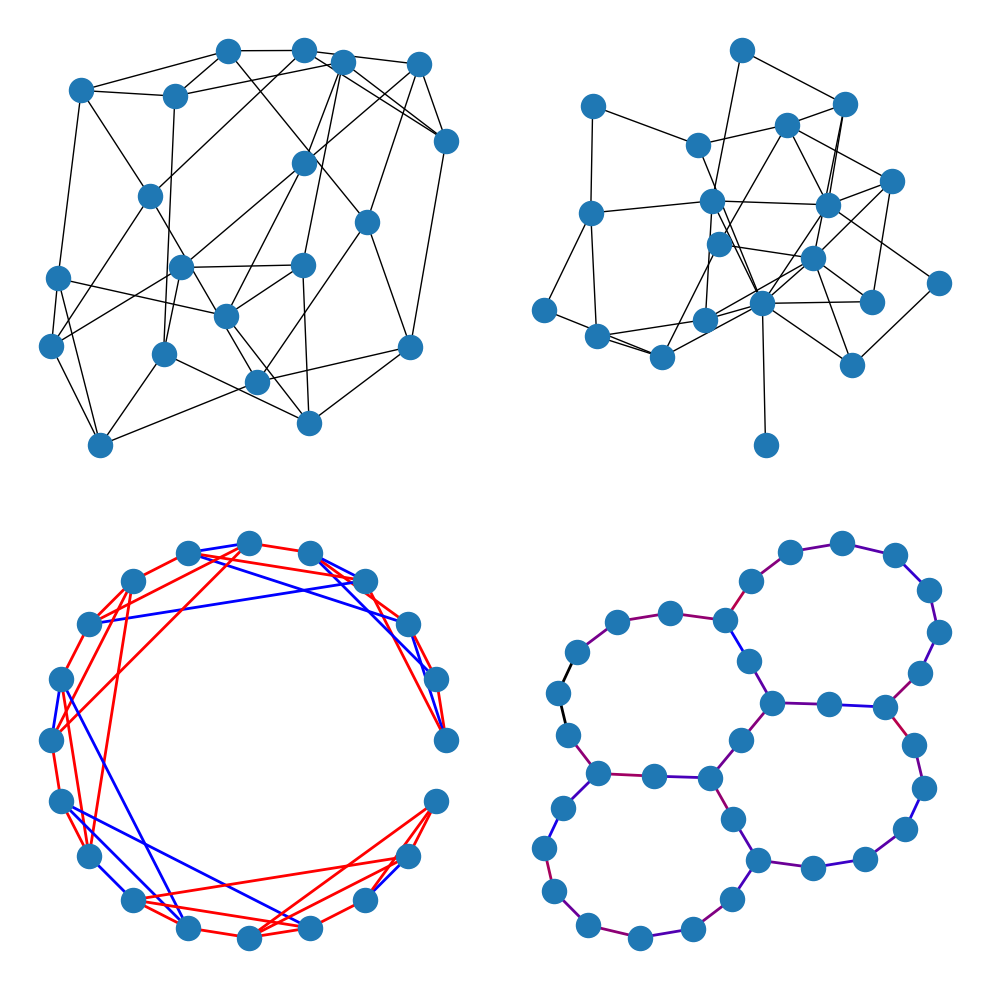

In [64]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
nx.draw(graph1, ax=axs[0])
nx.draw_kamada_kawai(graph2, ax=axs[1])
nx.draw(graph3, nx.circular_layout(graph3), ax=axs[2], edge_color=["r" if val[2]["weight"] == -1 else "b" for val in graph3.edges(data=True)], width=2)
nx.draw_kamada_kawai(graph4_, ax=axs[3], edge_color=edge_colors(graph4), width=2)
fig.tight_layout()